# NovaVida - Proyecto Corte 1

In [1]:
# Importamos las librerías necesarias
# NumPy nos ayuda a manejar arreglos (matrices, vectores, etc.)
# Pandas nos permite trabajar con tablas de datos (DataFrames), muy parecido a Excel
import numpy as np
import pandas as pd

In [2]:
# Cargamos el dataset desde el archivo CSV llamado 'dataset.csv'
# Este archivo contiene información sobre pacientes del hospital NovaVida
df = pd.read_csv('dataset.csv')

# Mostramos las primeras 5 filas del DataFrame para tener una vista previa de los datos
# Esto nos permite verificar que el archivo se cargó correctamente y conocer la estructura de los datos
df.head()

,id_paciente,fecha_ingreso,fecha_alta,especialidad,edad,genero,tipo_seguro,tiempo_espera_min,tiempo_consulta_min,costo_medicamentos,costo_examenes,costo_total,reingreso_30_dias,satisfaccion_paciente,medico_asignado,turno,medicos_por_especialidad,nivel_complejidad,pacientes_por_dia
0,1,2025-01-11 23:15:00,2025-01-12 01:26:00,Ginecología,79,F,Público,28.37,29.10,61.48,86.46,147.94,False,2,Dr./Dra. Molina,mañana,11,Alto,90
1,2,2025-01-01 14:20:00,2025-01-01 18:42:00,Urología,31,M,Privado,37.78,19.22,22.12,60.83,82.95,False,4,Dr./Dra. Rivas,tarde,11,Bajo,110
2,3,2025-01-27 11:58:00,2025-01-27 13:23:00,Pediatría,74,F,Público,416.00,30.46,NaN,90.45,172.40,True,4,Dr./Dra. Herrera,noche,4,Alto,118
3,4,2025-01-08 20:04:00,2025-01-08 20:34:00,Endocrinología,30,F,Público,16.08,36.06,122.88,NaN,212.43,False,3,Dr./Dra. López,tarde,7,Alto,46
4,5,2025-01-05 08:25:00,2025-01-05 12:52:00,Ginecología,53,M,Privado,3.14,58.85,4.31,36.19,40.50,False,2,Dr./Dra. Salas,mañana,5,Bajo,113


## Comprender la estructura del dataset

**Objetivo:**

- ¿Cuántas filas?
- ¿Cuántas columnas?
- ¿Hay tipos incorrectos?
- ¿Fechas están como string?

In [3]:
# Dentro de un data frame, existe la propiedad llamada columns la cual nos va a devolver
# el nombre de las columnas. Simplemente ponemos el nombre del data frame y después un .columns
# esto sirve para ver la cantidad de datos con los que estamos trabajando
print(df.columns)

Index(['id_paciente', 'fecha_ingreso', 'fecha_alta', 'especialidad', 'edad',
       'genero', 'tipo_seguro', 'tiempo_espera_min', 'tiempo_consulta_min',
       'costo_medicamentos', 'costo_examenes', 'costo_total',
       'reingreso_30_dias', 'satisfaccion_paciente', 'medico_asignado',
       'turno', 'medicos_por_especialidad', 'nivel_complejidad',
       'pacientes_por_dia'],
      dtype='object')


In [4]:
# Para saber la cantidad de filas y columnas que tiene el data frame, usamos otra función
# de pandas. Este es el .shape que nos va a devolver el número de filas y el número de columnas.

# creamos dos variables, filas y columnas y que sean igual = dataframe.shape
filasData, columnasData = df.shape

# Imprimimos el número de filas
print("El número de filas es:", filasData)

# Ahora imprimimos el número de columnas
print("El número de columnas es:", columnasData)

El número de filas es: 100000
El número de columnas es: 19


In [5]:
# Convertimos la columna `fecha_ingreso` a tipo fecha/hora (datetime).
# `errors='coerce'` hace que cualquier valor inválido se transforme en `NaT`
# (Not a Time), en lugar de generar un error.

df['fecha_ingreso'] = pd.to_datetime(df['fecha_ingreso'], errors='coerce')
print(df['fecha_ingreso'].head())

0   2025-01-11 23:15:00
1   2025-01-01 14:20:00
2   2025-01-27 11:58:00
3   2025-01-08 20:04:00
4   2025-01-05 08:25:00
Name: fecha_ingreso, dtype: datetime64[ns]


In [6]:
# Mostramos información general del DataFrame
# La función .info() nos proporciona:
# - El número total de entradas (filas)
# - El nombre de cada columna
# - El número de valores no nulos en cada columna
# - El tipo de dato de cada columna (int64, float64, object, bool, etc.)
# - El uso de memoria del DataFrame
# Esto es útil para identificar valores faltantes y verificar los tipos de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 19 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   id_paciente               100000 non-null  int64         
 1   fecha_ingreso             100000 non-null  datetime64[ns]
 2   fecha_alta                100000 non-null  object        
 3   especialidad              100000 non-null  object        
 4   edad                      100000 non-null  int64         
 5   genero                    100000 non-null  object        
 6   tipo_seguro               100000 non-null  object        
 7   tiempo_espera_min         100000 non-null  float64       
 8   tiempo_consulta_min       100000 non-null  float64       
 9   costo_medicamentos        90000 non-null   float64       
 10  costo_examenes            90000 non-null   float64       
 11  costo_total               90000 non-null   float64       
 12  rei

In [7]:
# Resumen estadístico de las variables numéricas
# Para esto usamos la función .describe() que nos va a dar un resumen estadístico

resumen_estadistico = df.describe()
print(resumen_estadistico)

         id_paciente                  fecha_ingreso           edad  \
count  100000.000000                         100000  100000.000000   
mean    50000.500000  2025-01-15 22:56:11.678400512      46.862690   
min         1.000000            2025-01-01 00:00:00       0.000000   
25%     25000.750000            2025-01-08 12:19:00      23.000000   
50%     50000.500000            2025-01-15 22:34:00      47.000000   
75%     75000.250000            2025-01-23 09:35:15      71.000000   
max    100000.000000            2025-01-31 00:00:00      94.000000   
std     28867.657797                            NaN      27.422834   

       tiempo_espera_min  tiempo_consulta_min  costo_medicamentos  \
count      100000.000000        100000.000000        90000.000000   
mean           46.353356            35.041379           40.010722   
min             1.000000            10.000000            0.000000   
25%            11.290000            22.540000           11.500000   
50%            21.510000

## Identificación de la calidad de los registros

**Preguntas clave:**

- ¿Faltan costos?
- ¿Falta satisfacción?
- ¿Hay tiempos vacíos?

In [8]:
# Calculamos la cantidad de valores nulos por cada columna
valores_nulos = df.isnull().sum()

# Calculamos el porcentaje de valores nulos por columna
# (mean sobre booleanos: True=1, False=0)
porcentaje_nulos = df.isnull().mean() * 100

# Unimos ambos resultados en una sola tabla para facilitar el análisis
resumen_nulos = pd.DataFrame({
    "valores_nulos": valores_nulos,
    "porcentaje_nulos": porcentaje_nulos
})

# Mostramos solo las columnas que tienen al menos un valor nulo
resumen_nulos[resumen_nulos["valores_nulos"] > 0]

,valores_nulos,porcentaje_nulos
costo_medicamentos,10000,10.0
costo_examenes,10000,10.0
costo_total,10000,10.0


In [16]:
# Corregimos celdas vacías -> Importante: No se debe usar el método .dropna() porque eliminaría filas completas, lo cual no es deseable en este caso. En su lugar, se debe usar el método .fillna(0) para reemplazar los valores vacíos por 0, lo que permitirá recalcular el costo_total correctamente sin perder datos importantes.

# Recalcular correctamente costo_total, tratando los valores vacíos como 0 usando .fillna(0)
df["costo_total"] = df["costo_medicamentos"].fillna(0) + df["costo_examenes"].fillna(0)

# Verificamos que no hayan valores vacíos
df[["costo_medicamentos", "costo_examenes", "costo_total"]].isnull().sum()

costo_medicamentos    10000
costo_examenes        10000
costo_total               0
dtype: int64

## Validación de coherencia lógica
### 1. Costos coherentes

In [17]:
# Creamos una columna auxiliar que suma los costos de medicamentos y exámenes
df['suma_costos'] = df['costo_medicamentos'] + df['costo_examenes']

# Contamos cuántas filas tienen discrepancias entre la suma calculada y el costo_total registrado
# Esto nos ayuda a identificar inconsistencias en los datos de costos
discrepancias = (df['suma_costos'] != df['costo_total']).sum()
print(f"Número de discrepancias encontradas: {discrepancias}")

Número de discrepancias encontradas: 19001


Si esta incosistencia es:

- <5% → error menor
- 10–20% → problema moderado
- 30% → problema estructural grave
- 50% → el dataset financiero es poco confiable

In [18]:
# Calculamos el total de registros del DataFrame
total_registros = len(df)

# Calculamos el porcentaje de registros con discrepancias:
# (número de discrepancias / total de registros) * 100
porcentaje_discrepancias = (discrepancias / total_registros) * 100

# Mostramos el resultado con un formato más legible
print(f"Porcentaje de discrepancias en costo_total: {porcentaje_discrepancias:.2f}%")

Porcentaje de discrepancias en costo_total: 19.00%


In [21]:
# Calculamos la diferencia entre el costo_total registrado y la suma real de costos
# Esta columna nos ayuda a identificar discrepancias en la facturación:
# - Si diferencia_costos = 0: el costo_total es correcto
# - Si diferencia_costos ≠ 0: hay una inconsistencia que debe investigarse

df['diferencia_costos'] = df['costo_total'] - (df['costo_medicamentos'] + df['costo_examenes'])

# Generamos estadísticas descriptivas de la columna diferencia_costos
# Esto nos permite analizar:
# - count: cuántos registros tienen esta diferencia calculada (excluye NaN)
# - mean: diferencia promedio (si es cercana a 0, la mayoría de registros son coherentes)
# - std: desviación estándar (qué tan dispersas están las diferencias)
# - min/max: rangos de las discrepancias encontradas
# - 25%, 50%, 75%: percentiles para entender la distribución de errores
df['diferencia_costos'].describe()

count    80999.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: diferencia_costos, dtype: float64

In [22]:
# Primero creamos la columna flag_inconsistencia_costos
# Marcamos como True las filas donde existe una diferencia entre costo_total y la suma de costos
df['flag_inconsistencia_costos'] = df['diferencia_costos'] != 0

# Ahora agrupamos por especialidad para ver qué especialidades tienen más inconsistencias
df.groupby('especialidad')['flag_inconsistencia_costos'].mean().sort_values(ascending=False)

especialidad
Dermatología         0.198581
Traumatología        0.195204
Cardiología          0.194761
Oftalmología         0.191625
Endocrinología       0.191096
Gastroenterología    0.190296
Oncología            0.189687
Ginecología          0.189161
Pediatría            0.187419
Reumatología         0.186937
Urología             0.186135
Neurología           0.185450
Emergencias          0.183917
Name: flag_inconsistencia_costos, dtype: float64

In [23]:
# Analizamos la relación entre inconsistencias de costos y la satisfacción del paciente
# Agrupamos los datos por el indicador de inconsistencia (True/False) y calculamos
# el promedio de satisfacción para cada grupo
# 
# Esto nos permite responder:
# - ¿Los pacientes con inconsistencias en costos están menos satisfechos?
# - ¿Hay una correlación entre errores administrativos y percepción del servicio?
#
# Resultado esperado:
# - flag_inconsistencia_costos = False: satisfacción promedio de pacientes sin errores
# - flag_inconsistencia_costos = True: satisfacción promedio de pacientes con errores de facturación
df.groupby('flag_inconsistencia_costos')['satisfaccion_paciente'].mean()

flag_inconsistencia_costos
False    2.987988
True     2.996421
Name: satisfaccion_paciente, dtype: float64

**Interpretación del resultado:**

`flag_inconsistencia_costos = False` → satisfacción promedio: 2.986154
Pacientes SIN inconsistencias de facturación tienen una satisfacción promedio de ~2.99

`flag_inconsistencia_costos = True` → satisfacción promedio: 2.995435  
Pacientes CON inconsistencias de facturación tienen una satisfacción promedio de ~3.00

**En términos estratégicos:**

- El paciente no percibe errores administrativos.
- El problema financiero es interno, no de experiencia del usuario.
- No está impactando directamente la calidad percibida.

**Este hallazgo implica:**

- El problema principal probablemente no es facturación.
- La caída del margen puede venir de otra parte.
- La insatisfacción no está explicada por errores de costos.

### Tiempos negativos o absurdos

In [26]:
# Validación de valores negativos en tiempos de atención
# Un tiempo negativo no es lógico, por lo que se considera inconsistencia de calidad de datos.

# Filas con tiempo de espera negativo
tiempos_espera_negativos = df[df['tiempo_espera_min'] < 0]

# Filas con tiempo de consulta negativo
tiempos_consulta_negativos = df[df['tiempo_consulta_min'] < 0]

# Resumen rápido de inconsistencias encontradas
print(f"Registros con tiempo_espera_min negativo: {len(tiempos_espera_negativos)}")
print(f"Registros con tiempo_consulta_min negativo: {len(tiempos_consulta_negativos)}")

# Vista previa de registros inconsistentes (opcional)
tiempos_espera_negativos.head(), tiempos_consulta_negativos.head()

# Estadística descriptiva de la variable tiempo de espera
df['tiempo_espera_min'].describe()

Registros con tiempo_espera_min negativo: 0
Registros con tiempo_consulta_min negativo: 0


count    100000.000000
mean         46.353356
std         115.569158
min           1.000000
25%          11.290000
50%          21.510000
75%          31.740000
max         719.000000
Name: tiempo_espera_min, dtype: float64

## Detección de Outliers

Para tiempos de espera:

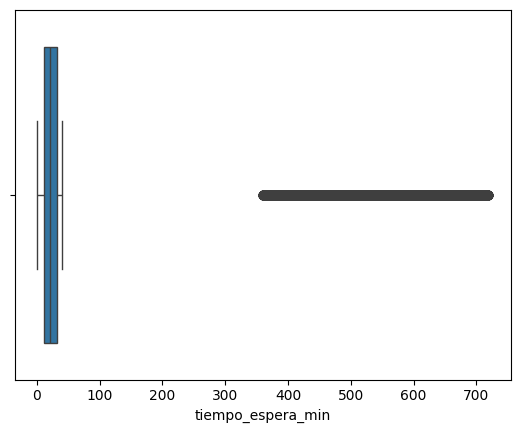

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

# Crear un gráfico de caja (boxplot) para visualizar la distribución de 
# tiempo_espera_min y detectar outliers de forma visual
# 
# El boxplot muestra:
# - La mediana (línea central en la caja)
# - El rango intercuartílico (la caja, entre Q1 y Q3)
# - Los bigotes (whiskers) que se extienden hasta 1.5*IQR
# - Los puntos fuera de los bigotes son outliers (5% de los datos)
sns.boxplot(x=df['tiempo_espera_min'])
plt.show()

También puedes usar IQR:

In [28]:
# Cálculo del rango intercuartílico (IQR) para detectar outliers en tiempo_espera_min
# 
# El método IQR (Interquartile Range) es una técnica estadística robusta para identificar
# valores atípicos que no se ven afectados por valores extremos.
#
# Pasos del método:
# 1. Q1 (primer cuartil): 25% de los datos están por debajo de este valor
# 2. Q3 (tercer cuartil): 75% de los datos están por debajo de este valor
# 3. IQR = Q3 - Q1: mide la dispersión del 50% central de los datos
# 4. Los outliers son valores que caen fuera del rango [Q1 - 1.5*IQR, Q3 + 1.5*IQR]

# Calculamos el primer cuartil (percentil 25)
# Ejemplo: si Q1 = 11.29, el 25% de los pacientes esperó menos de 11.29 minutos
Q1 = df['tiempo_espera_min'].quantile(0.25)

# Calculamos el tercer cuartil (percentil 75)
# Ejemplo: si Q3 = 31.74, el 75% de los pacientes esperó menos de 31.74 minutos
Q3 = df['tiempo_espera_min'].quantile(0.75)

# Calculamos el rango intercuartílico (IQR)
# Este valor representa la dispersión del 50% central de los datos
# Ejemplo: IQR = 31.74 - 11.29 = 20.45 minutos
IQR = Q3 - Q1

# Filtramos los outliers usando el criterio de Tukey:
# - Outliers inferiores: valores < Q1 - 1.5*IQR
# - Outliers superiores: valores > Q3 + 1.5*IQR
# 
# El factor 1.5 es el estándar estadístico:
# - Captura aproximadamente el 99.3% de los datos en distribuciones normales
# - Valores fuera de este rango son considerados anómalos y requieren investigación
#
# Interpretación clínica:
# - Tiempos muy bajos: pueden indicar pacientes prioritarios o errores de registro
# - Tiempos muy altos: saturación del servicio, problemas de gestión, o emergencias
outliers = df[(df['tiempo_espera_min'] < Q1 - 1.5*IQR) |
              (df['tiempo_espera_min'] > Q3 + 1.5*IQR)]

## Análisis Univariado

### Distribución tiempos de espera

Preguntas:

- ¿Es simétrica?
- ¿Está sesgada?
- ¿Hay concentración en valores altos?

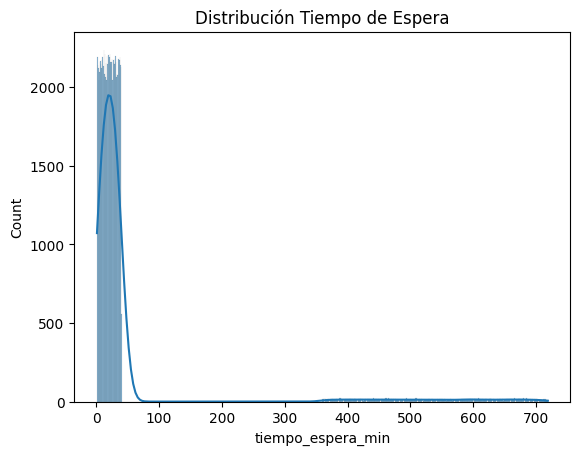

In [30]:
sns.histplot(df['tiempo_espera_min'], kde=True)
plt.title("Distribución Tiempo de Espera")
plt.show()

### Satisfacción

<Axes: xlabel='satisfaccion_paciente', ylabel='count'>

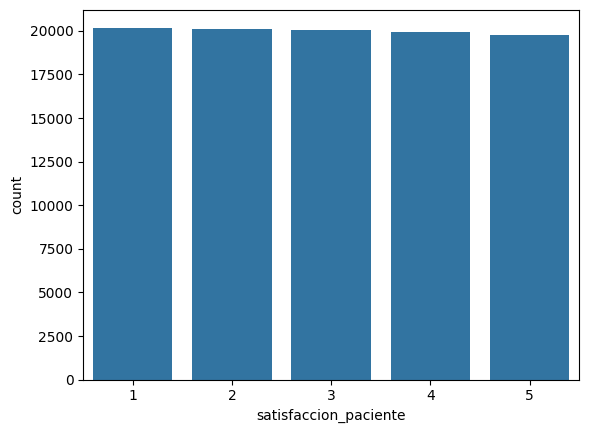

In [31]:
df['satisfaccion_paciente'].value_counts()
sns.countplot(x='satisfaccion_paciente', data=df)

### Reingresos

In [33]:
# Análisis de la proporción de reingresos en los primeros 30 días
# 
# Esta métrica es crítica para evaluar la calidad de atención del hospital:
# - Reingresos altos pueden indicar:
#   * Alta temprana inadecuada
#   * Tratamiento incompleto o inefectivo
#   * Falta de seguimiento post-alta
#   * Complicaciones no previstas
#
# normalize=True convierte los conteos en proporciones (porcentajes en decimal):
# - False: pacientes que NO reingresaron (mayoría esperada)
# - True: pacientes que SÍ reingresaron dentro de 30 días
#
# Benchmark de la industria hospitalaria:
# - Tasa de reingreso < 10%: excelente calidad de atención
# - Tasa de reingreso 10-15%: aceptable
# - Tasa de reingreso > 15%: requiere intervención urgente
#
# Esta información es clave para:
# - Evaluar efectividad del tratamiento
# - Identificar especialidades con problemas de calidad
# - Calcular costos ocultos (reingresos no planificados)
# - Mejorar protocolos de alta y seguimiento

df['reingreso_30_dias'].value_counts(normalize=True)

reingreso_30_dias
False    0.88039
True     0.11961
Name: proportion, dtype: float64

## Análisis Relacional

### Especialidad vs Tiempo de Espera
Si ciertas especialidades tienen espera mucho mayor → posible cuello de botella.

In [35]:
# Análisis de correlación entre Tiempo de Espera y Satisfacción del Paciente
# 
# Esta métrica es crítica para entender si los tiempos de espera prolongados
# impactan negativamente la percepción de calidad del servicio.
#
# Agrupamos por especialidad y calculamos:
# - Tiempo de espera promedio (en minutos)
# - El resultado nos permite identificar:
#   * Especialidades con tiempos de espera más altos (posibles cuellos de botella)
#   * Necesidad de reasignación de recursos médicos
#   * Priorización de mejoras operativas
#
# Ordenamos de mayor a menor (descendente) para visualizar primero
# las especialidades con mayores problemas de tiempo de espera.
#
# Interpretación estratégica:
# - Si una especialidad tiene >60 min promedio: requiere intervención urgente
# - Si hay gran variación entre especialidades: problema de distribución de recursos
# - Comparar con satisfacción_paciente para validar impacto en experiencia

df.groupby('especialidad')['tiempo_espera_min'].mean().sort_values(ascending=False)

especialidad
Neurología           47.363649
Emergencias          47.334102
Urología             46.855543
Ginecología          46.770491
Oncología            46.482389
Oftalmología         46.444750
Gastroenterología    46.369803
Pediatría            46.146533
Reumatología         46.060237
Traumatología        46.040268
Endocrinología       45.793815
Cardiología          45.470297
Dermatología         45.425274
Name: tiempo_espera_min, dtype: float64

### Especialidad vs Costo Total

Aquí se pueden detectar:

- Especialidades caras
- Especialidades poco rentables

In [37]:
# Análisis de Costos por Especialidad
# 
# Este análisis agrupa los datos por especialidad médica y calcula el costo promedio
# de atención para cada una. Esto permite identificar:
#
# 1. Especialidades con mayores costos operativos
#    - Pueden requerir más recursos, equipos o medicamentos caros
#    - Impactan directamente la rentabilidad del hospital
#
# 2. Especialidades con menores costos
#    - Pueden ser más eficientes operacionalmente
#    - Podrían servir como referencia de mejores prácticas
#
# 3. Oportunidades de optimización
#    - Comparar costos entre especialidades similares
#    - Identificar especialidades que requieren renegociación de proveedores
#    - Evaluar si hay duplicación de servicios
#
# El método .sort_values(ascending=False) ordena de mayor a menor costo,
# permitiendo visualizar primero las especialidades más costosas.
#
# Interpretación estratégica:
# - Si el costo más alto es >3x el más bajo: hay gran dispersión, revisar eficiencia
# - Si hay especialidades rentables y otras no: considerar modelo de negocio mixto
# - Comparar con volumen de pacientes (pacientes_por_dia) para evaluar margen real

df.groupby('especialidad')['costo_total'].mean().sort_values(ascending=False)

especialidad
Emergencias          109.767791
Ginecología          109.334035
Urología             109.182625
Neurología           109.092180
Pediatría            108.684823
Endocrinología       108.002111
Oncología            107.836831
Traumatología        107.681328
Reumatología         107.677484
Gastroenterología    107.522186
Dermatología         106.871682
Oftalmología         106.768974
Cardiología          106.619284
Name: costo_total, dtype: float64

### Correlaciones numéricas

Nos enfocamos especialmente en:
- tiempo_espera_min vs satisfaccion
- tiempo_consulta_min vs costo_total
- costo_total vs reingreso_30_dias

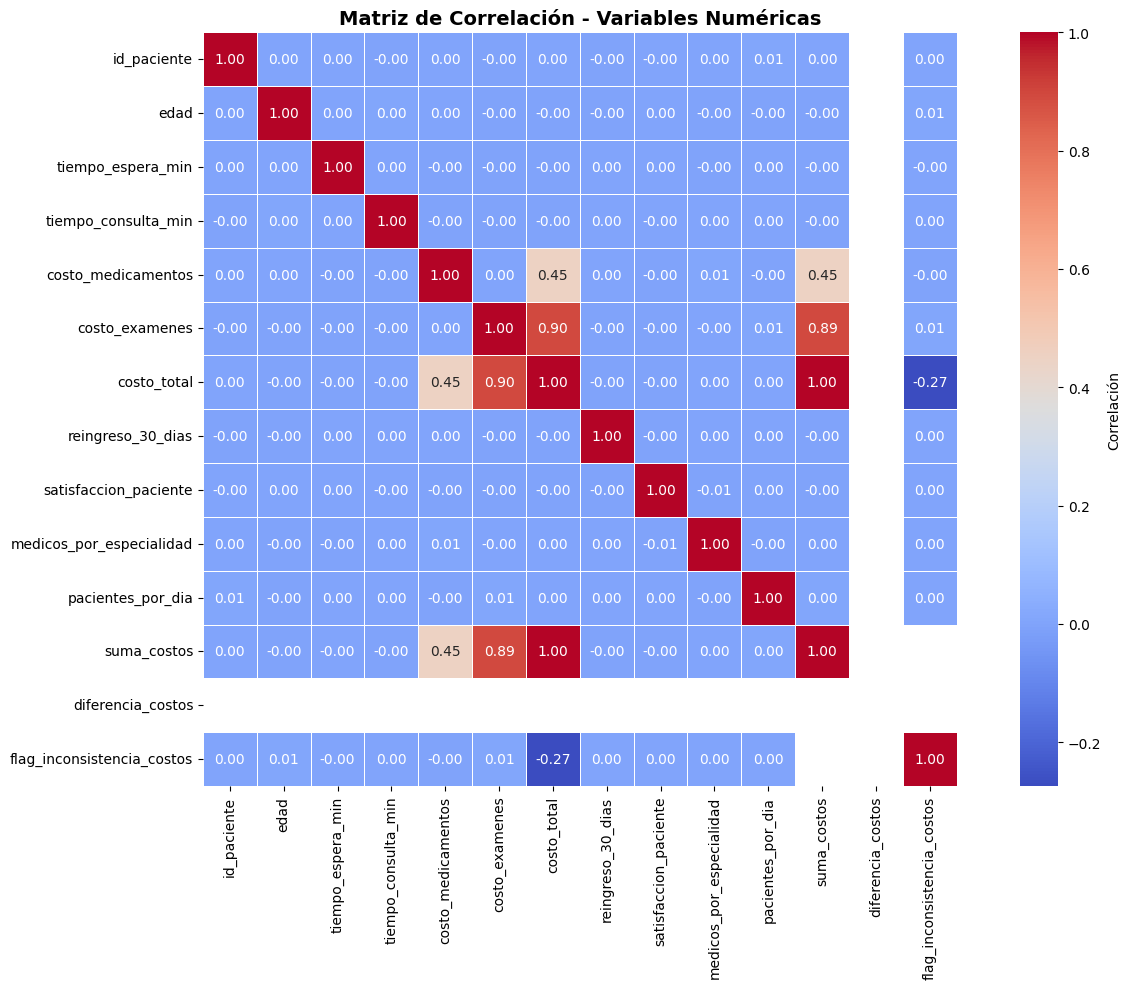

In [41]:
# Calcular la matriz de correlación de todas las variables numéricas
corr = df.corr(numeric_only=True)

# Crea un mapa de calor más legible con mejor tamaño y formato
plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', 
            cbar_kws={'label': 'Correlación'}, 
            square=True, linewidths=0.5)
plt.title("Matriz de Correlación - Variables Numéricas", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
